<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [1]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [2]:
df=pd.read_csv("dataset\\dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


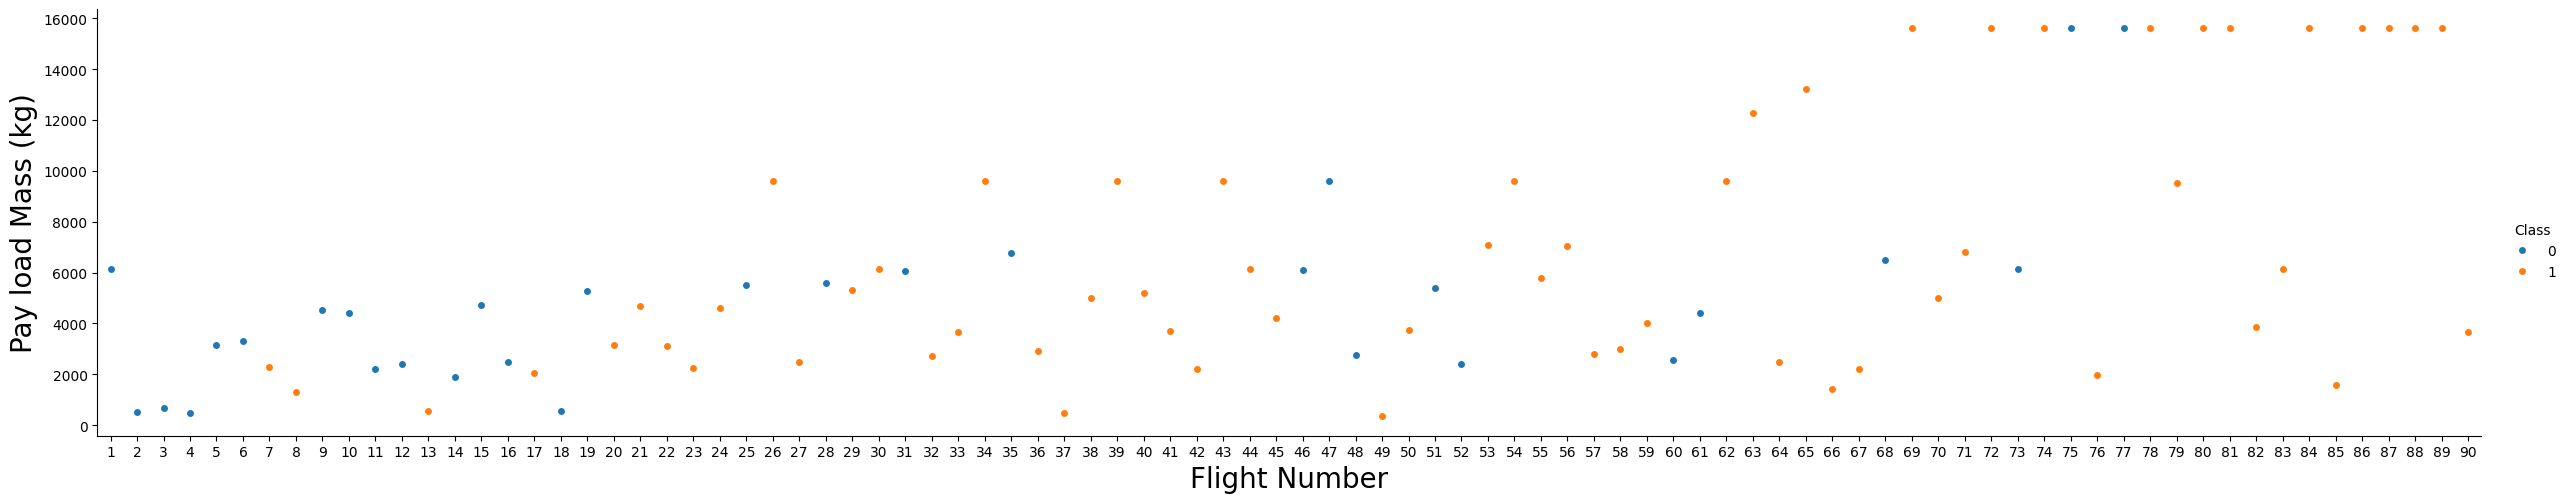

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


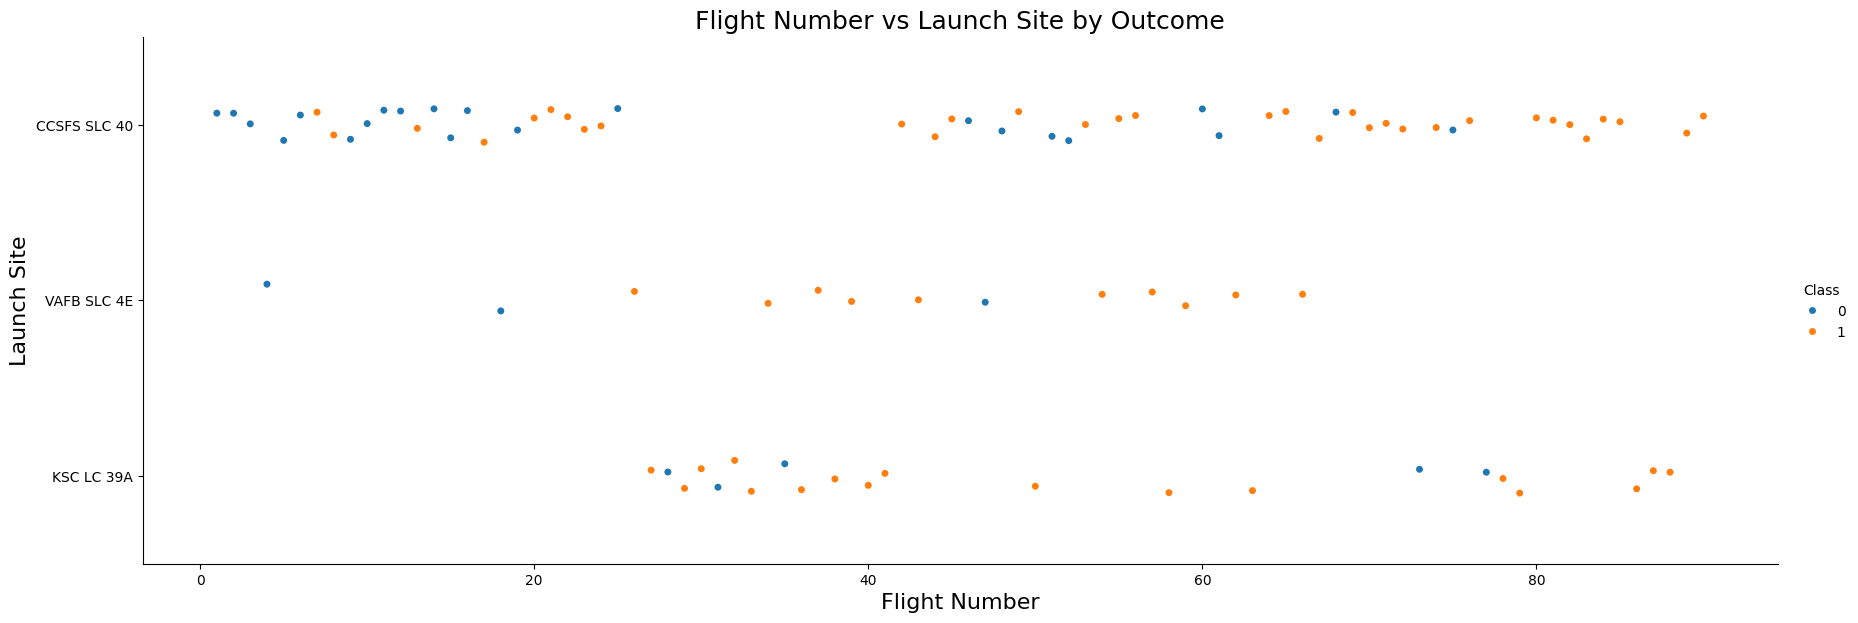

In [11]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=3, height=6, kind="strip")
plt.xlabel("Flight Number", fontsize=16)
plt.ylabel("Launch Site", fontsize=16)
plt.title("Flight Number vs Launch Site by Outcome", fontsize=18)
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


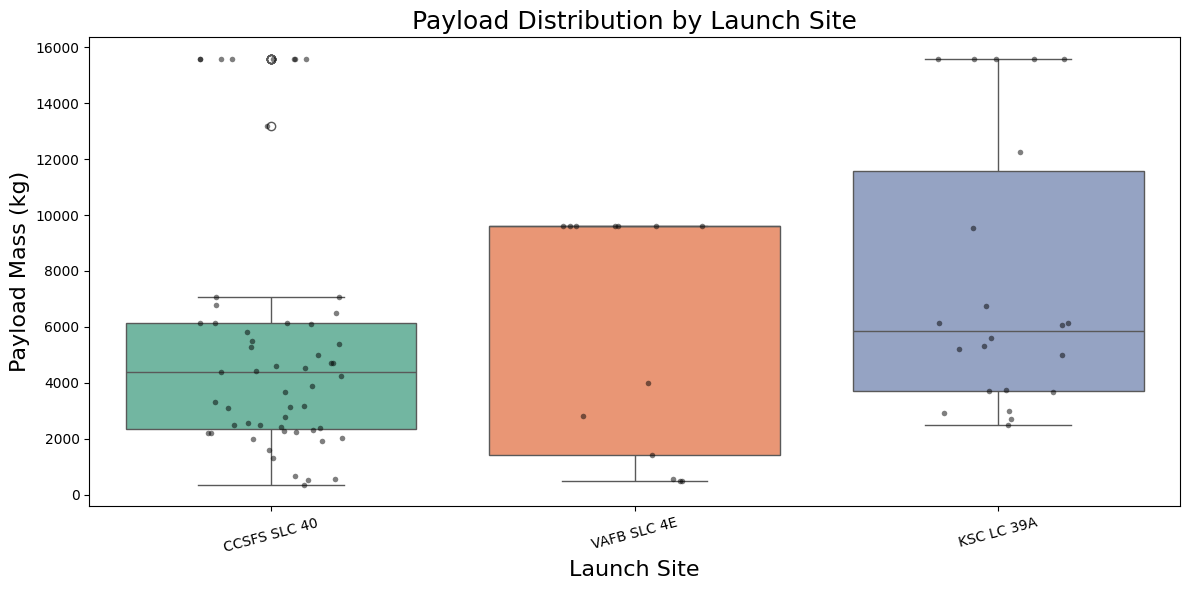

In [13]:
# Plot payload distribution by launch site (best for numeric vs categorical comparison)
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="LaunchSite",
    y="PayloadMass",
    hue="LaunchSite",
    data=df,
    palette="Set2",
    legend=False
 )
sns.stripplot(
    x="LaunchSite",
    y="PayloadMass",
    data=df,
    color="black",
    alpha=0.5,
    size=4,
    jitter=0.2
 )
plt.xlabel("Launch Site", fontsize=16)
plt.ylabel("Payload Mass (kg)", fontsize=16)
plt.title("Payload Distribution by Launch Site", fontsize=18)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


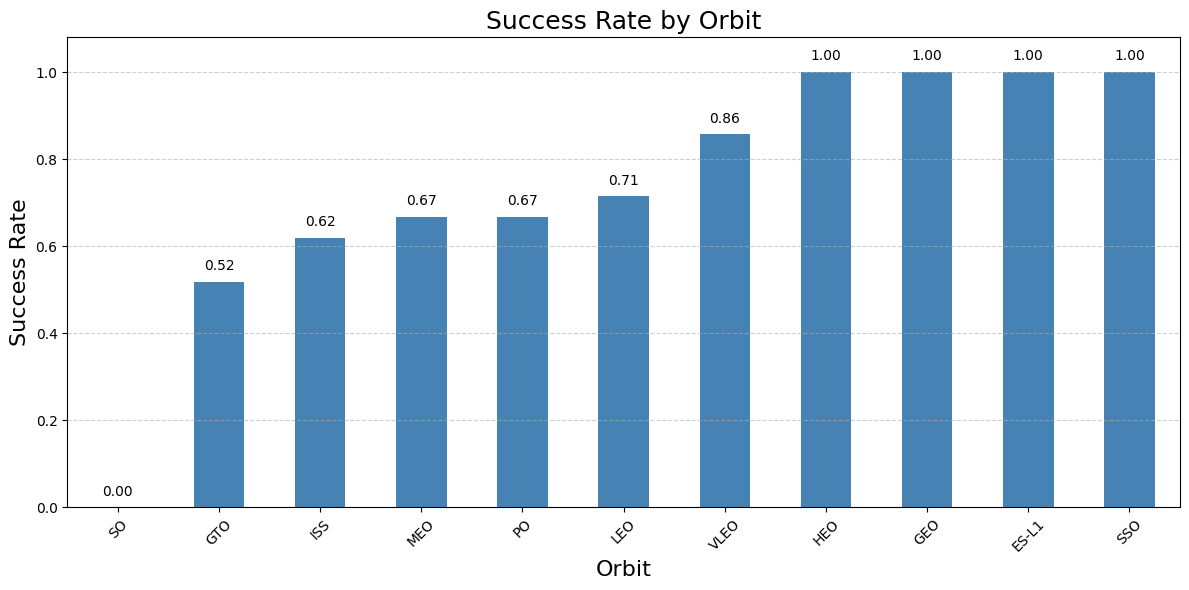

In [6]:
# Calculate success rate for each orbit type
orbit_success_rate = df.groupby('Orbit')['Class'].mean().sort_values()

# Plot bar chart from the calculated success-rate series
plt.figure(figsize=(12, 6))
ax = orbit_success_rate.plot(kind='bar', color='steelblue')

# Add value labels on top of each bar
for i, value in enumerate(orbit_success_rate.values):
    ax.text(i, value + 0.02, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

# Add horizontal grid lines for easier comparison
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.xlabel('Orbit', fontsize=16)
plt.ylabel('Success Rate', fontsize=16)
plt.title('Success Rate by Orbit', fontsize=18)
plt.ylim(0, 1.08)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


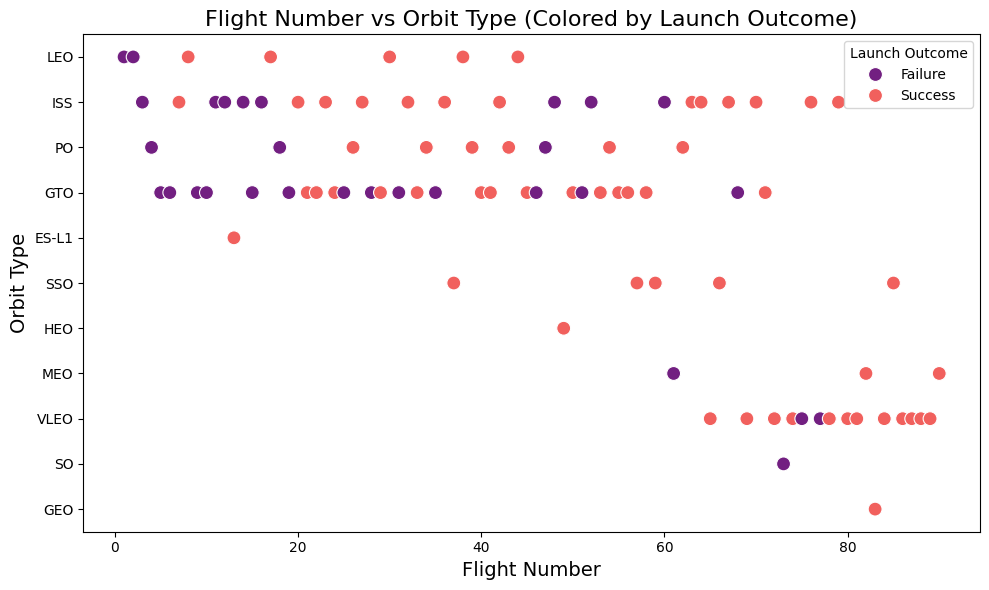

In [7]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
# Set up the plot
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x='FlightNumber', y='Orbit', hue='Class', data=df, palette='magma', s=100)

# Customize labels and title
plt.title('Flight Number vs Orbit Type (Colored by Launch Outcome)', fontsize=16)
plt.xlabel('Flight Number', fontsize=14)
plt.ylabel('Orbit Type', fontsize=14)

# Update the legend with correct labels
handles, _ = scatter.get_legend_handles_labels()
scatter.legend(handles=handles, title='Launch Outcome', labels=['Failure', 'Success'], loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


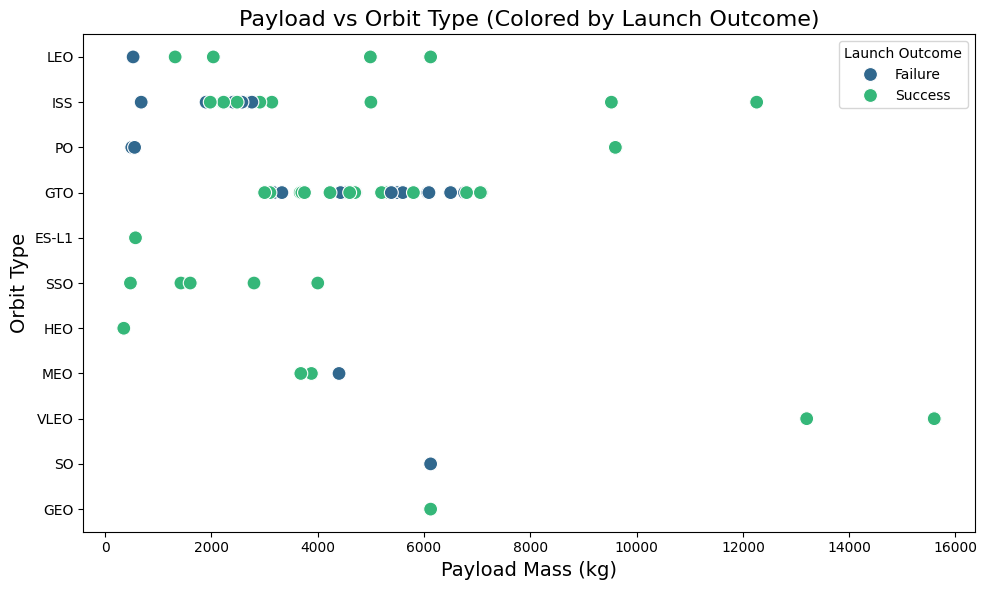

In [8]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value

# Set up the plot
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x='PayloadMass', y='Orbit', hue='Class', data=df, palette='viridis', s=100)

# Customize labels and title
plt.title('Payload vs Orbit Type (Colored by Launch Outcome)', fontsize=16)
plt.xlabel('Payload Mass (kg)', fontsize=14)
plt.ylabel('Orbit Type', fontsize=14)

# Update the legend with correct labels
handles, _ = scatter.get_legend_handles_labels()
scatter.legend(handles=handles, title='Launch Outcome', labels=['Failure', 'Success'], loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [9]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

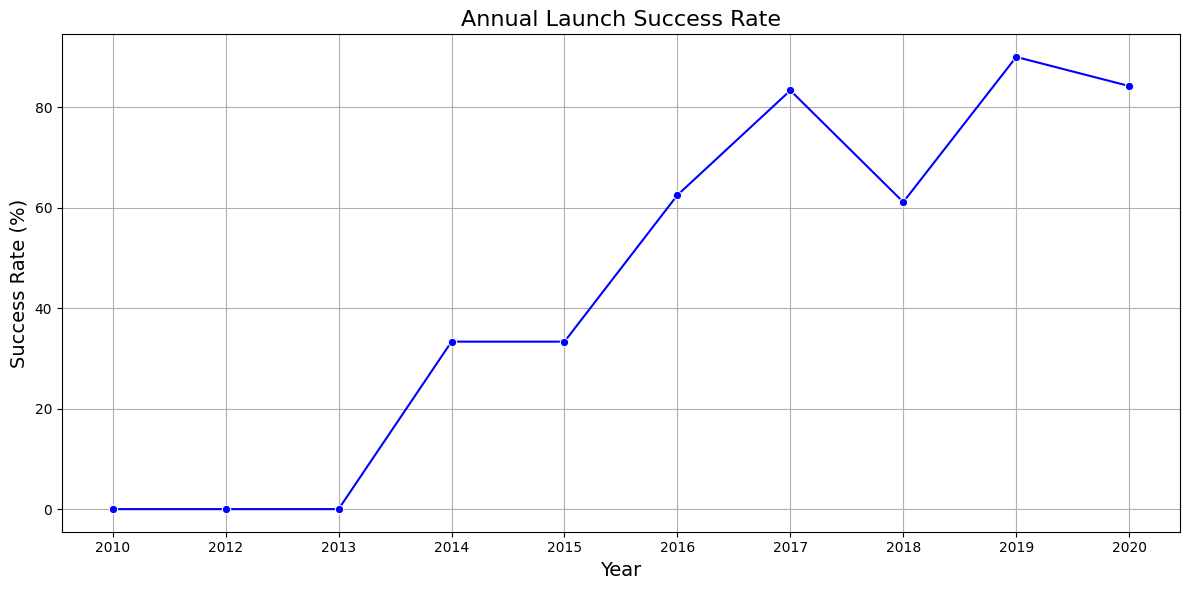

In [10]:
df['Year'] = Extract_year(df['Date'])

# Calculate success rate per year
success_rate = df.groupby('Year')['Class'].mean() * 100

# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
plt.figure(figsize=(12, 6))
sns.lineplot(x=success_rate.index, y=success_rate.values, marker='o', color='b')

# Customize labels and title
plt.title('Annual Launch Success Rate', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Success Rate (%)', fontsize=14)
plt.xticks(success_rate.index)
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Correlation Analysis: All Variables vs Launch Outcome

To understand which features have the strongest relationship with a successful first-stage landing, we compute the **Pearson / point-biserial correlation** of every numeric feature with `Class` (0 = failure, 1 = success). Categorical variables (`Orbit`, `LaunchSite`, `LandingPad`, `Serial`) are one-hot-encoded before computing correlations, so we can rank individual categories as well.

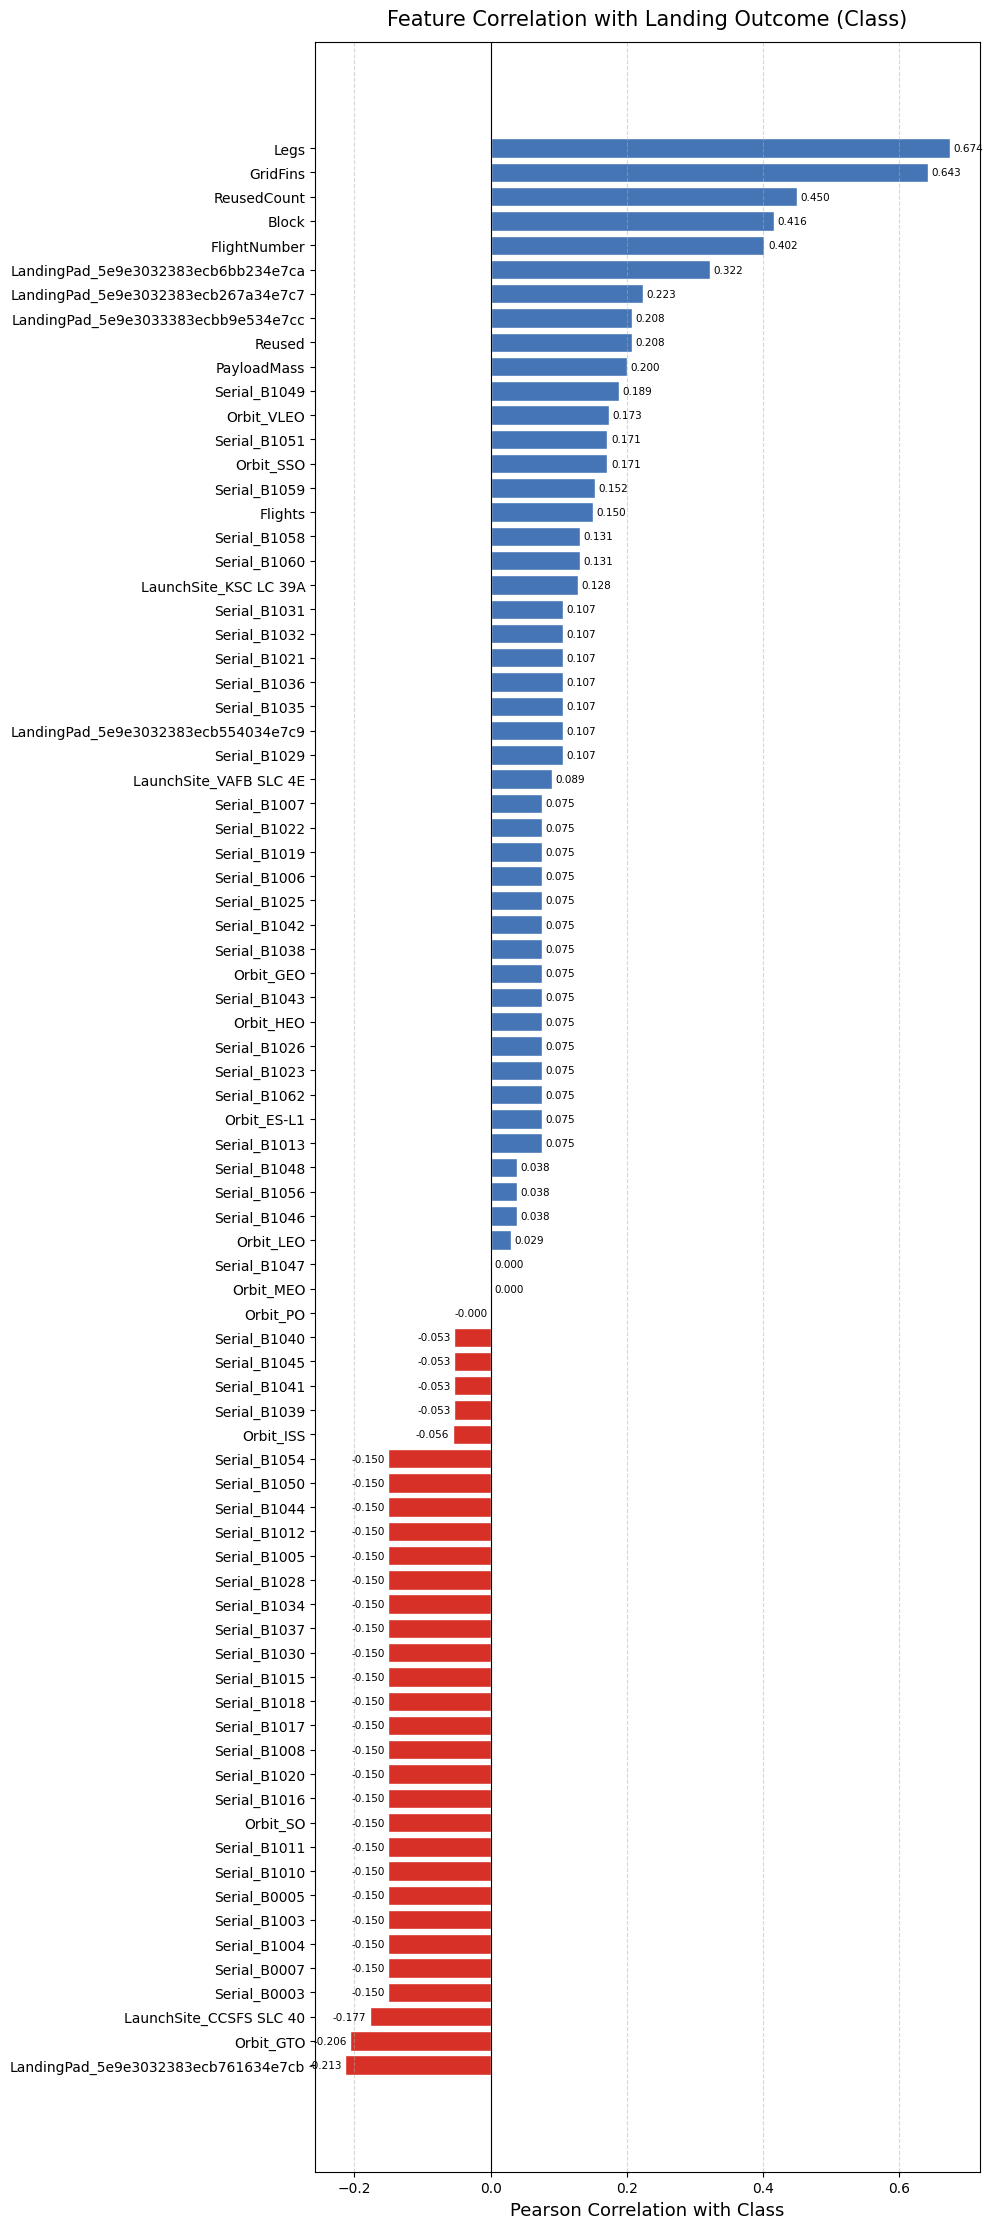


Top 10 features by |correlation| with Class:
Legs                                   0.673825
GridFins                               0.642540
ReusedCount                            0.450189
Block                                  0.416015
FlightNumber                           0.401923
LandingPad_5e9e3032383ecb6bb234e7ca    0.322329
LandingPad_5e9e3032383ecb267a34e7c7    0.223495
LandingPad_5e9e3032383ecb761634e7cb    0.213201
LandingPad_5e9e3033383ecbb9e534e7cc    0.208013
Reused                                 0.207582


In [14]:
# --- Correlation Analysis: All Variables vs Class ---

# 1. One-hot encode categorical columns
cat_cols = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
df_encoded = pd.get_dummies(df[cat_cols + ['FlightNumber', 'PayloadMass', 'Flights',
                                            'GridFins', 'Reused', 'Legs', 'Block',
                                            'ReusedCount', 'Class']],
                            columns=cat_cols)

# 2. Compute Pearson correlation with Class and drop Class itself
corr_with_class = df_encoded.corr()['Class'].drop('Class').sort_values()

# 3. Separate positive and negative correlations for colouring
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_with_class.values]

# 4. Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(corr_with_class) * 0.28)))
bars = ax.barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor='white')

# Annotate each bar with its value
for bar, val in zip(bars, corr_with_class.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=7.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Class', fontsize=13)
ax.set_title('Feature Correlation with Landing Outcome (Class)', fontsize=15, pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Print top 10 features by absolute correlation
print('\nTop 10 features by |correlation| with Class:')
print(corr_with_class.abs().sort_values(ascending=False).head(10).to_string())

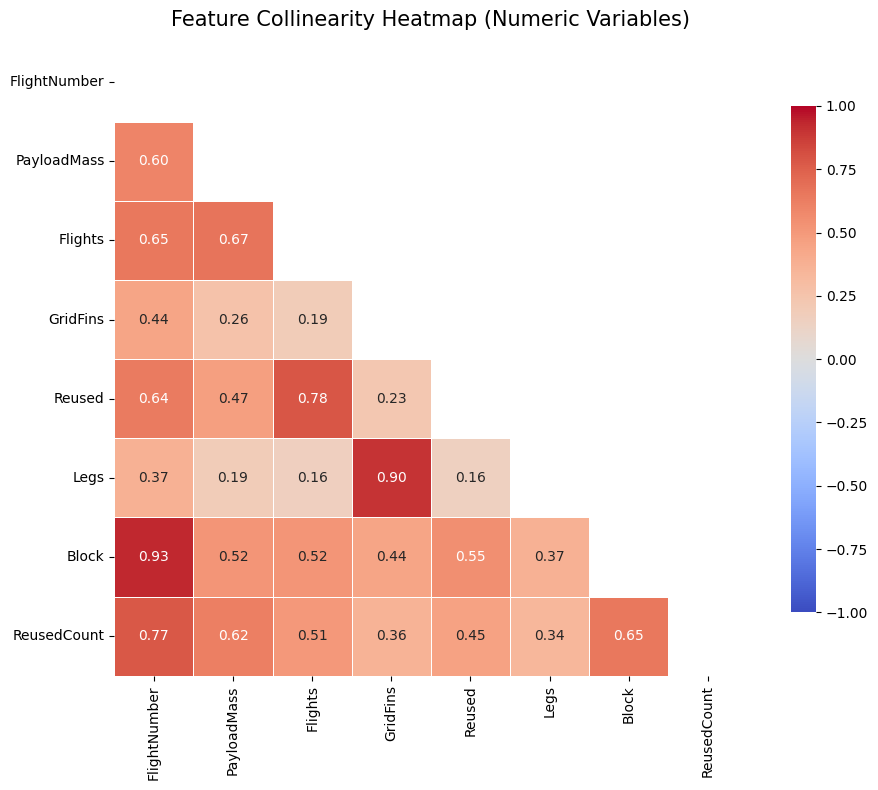

Highly collinear pairs (|r| > 0.7):
  FlightNumber         <-> Block                 r = 0.932
  GridFins             <-> Legs                  r = 0.902
  Flights              <-> Reused                r = 0.783
  FlightNumber         <-> ReusedCount           r = 0.775

Variance Inflation Factor (VIF):
FlightNumber    17.183
Block            9.916
GridFins         6.122
Legs             5.743
Flights          4.372
ReusedCount      3.378
Reused           2.985
PayloadMass      2.451


In [15]:
# --- Collinearity Analysis among Explanatory Variables ---
num_cols = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 'Reused', 'Legs', 'Block', 'ReusedCount']
corr_feat = df[num_cols].corr()

# 1. Lower-triangle heatmap
mask = np.triu(np.ones_like(corr_feat, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_feat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Collinearity Heatmap (Numeric Variables)', fontsize=15, pad=12)
plt.tight_layout()
plt.show()

# 2. Flag highly collinear pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr_feat.columns)):
    for j in range(i + 1, len(corr_feat.columns)):
        r = corr_feat.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_feat.columns[i], corr_feat.columns[j], r))

print('Highly collinear pairs (|r| > 0.7):')
if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1:<20s} <-> {f2:<20s}  r = {r:.3f}')
else:
    print('  None found.')

# 3. Variance Inflation Factor (manual, no extra package needed)
print('\nVariance Inflation Factor (VIF):')
X_df = df[num_cols].dropna()
X_arr = X_df.values.astype(float)
vif_vals = {}
for idx, col in enumerate(num_cols):
    y = X_arr[:, idx]
    X_others = np.delete(X_arr, idx, axis=1)
    X_others = np.column_stack([np.ones(len(X_others)), X_others])
    coef, _, _, _ = np.linalg.lstsq(X_others, y, rcond=None)
    y_hat = X_others @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    vif_vals[col] = round(1 / (1 - r2), 3) if r2 < 1 else float('inf')

vif_series = pd.Series(vif_vals).sort_values(ascending=False)
print(vif_series.to_string())

### Collinearity Findings

#### Highly Collinear Pairs (|r| > 0.70)

| Feature A | Feature B | r | Risk |
|---|---|---|---|
| `FlightNumber` | `Block` | **0.932** | 🔴 Very high — almost perfectly collinear |
| `GridFins` | `Legs` | **0.902** | 🔴 Very high — both are recovery-hardware flags |
| `Flights` | `Reused` | **0.783** | 🟠 High — `Reused` is essentially a binary version of `Flights` |
| `FlightNumber` | `ReusedCount` | **0.775** | 🟠 High — program-wide flight count tracks reuse count closely |

---

#### Variance Inflation Factor (VIF)

VIF > 5 indicates serious multicollinearity; VIF > 10 is severe.

| Feature | VIF | Assessment |
|---|---|---|
| `FlightNumber` | **17.18** | ❌ Severe — should be dropped or replaced |
| `Block` | **9.92** | ⚠️ High — retain only if `FlightNumber` is removed |
| `GridFins` | **6.12** | ⚠️ Moderate–high |
| `Legs` | **5.74** | ⚠️ Moderate–high |
| `Flights` | **4.37** | ✅ Acceptable |
| `ReusedCount` | **3.38** | ✅ Acceptable |
| `Reused` | **2.99** | ✅ Acceptable |
| `PayloadMass` | **2.45** | ✅ Low — safest feature |

---

#### Feature Engineering Actions for Collinearity

1. **Drop `FlightNumber`** (VIF 17.18) — its information is already captured by `Block` (program generation) and `ReusedCount` (booster history). Keeping it alongside `Block` causes severe multicollinearity for linear/logistic models.

2. **Keep only one of `GridFins` / `Legs`** for linear models (r = 0.90). Both carry nearly identical information. Prefer `Legs` (higher correlation with `Class`). For tree-based models, both can be kept safely.

3. **Replace `Reused` with `ReusedCount`** — `Reused` (binary: ever reused?) is a lossy version of `ReusedCount` (how many times?), and the pair has r = 0.78. `ReusedCount` is strictly more informative.

4. **`Flights` vs `Reused`** (r = 0.78): `Flights` counts total booster flights regardless of reuse intent, while `Reused` is a flag. Combine them into a single `booster_experience` = `ReusedCount` feature and drop `Flights` and `Reused`.

5. **`PayloadMass`** is the least collinear feature (VIF 2.45) — always keep it; no action needed.

### Correlation Results & Interpretation

#### Top Positive Correlators (landing success ↑)
| Feature | r vs Class | VIF | Interpretation |
|---|---|---|---|
| `Legs` | **+0.674** | 5.74 | Strongest predictor — planned recovery hardware flag. Moderate collinearity with `GridFins` (r = 0.90). |
| `GridFins` | **+0.643** | 6.12 | Recovery-intent flag; nearly redundant with `Legs`. |
| `ReusedCount` | **+0.450** | 3.38 | Booster maturity — safe to keep (low VIF). |
| `Block` | **+0.416** | 9.92 | Design generation; **highly collinear** with `FlightNumber` (r = 0.93). |
| `FlightNumber` | **+0.402** | **17.18** | Program-wide learning curve; **severe multicollinearity** — see recommendations. |
| `LandingPad` (top pads) | +0.21 – +0.32 | — | Specific pads carry meaningful signal; categorical, no VIF applicable. |

#### Top Negative Correlators (landing success ↓)
| Feature | r vs Class | Interpretation |
|---|---|---|
| `LandingPad` (one pad) | **−0.213** | Used for heavier/riskier missions. |
| `Orbit_GTO` | **−0.206** | Heavy-lift orbit depletes recovery fuel. |
| `LaunchSite_CCSFS SLC 40` | **−0.177** | High-energy site correlated with more failures. |
| `Orbit_ISS` | **−0.056** | Tight trajectory constraints reduce recovery success. |

---

### Consolidated Feature Engineering Recommendations

> These recommendations integrate both **predictive power** (correlation vs `Class`) and **collinearity** (pairwise r, VIF) findings.

#### 1. Address Severe Multicollinearity First
- **Drop `FlightNumber`** (VIF 17.18) — it is almost perfectly collinear with `Block` (r = 0.93) and strongly with `ReusedCount` (r = 0.78). `Block` + `ReusedCount` already capture all information it carries, with far lower VIF.
- **Keep `Block`** (VIF 9.92, r vs Class +0.42) once `FlightNumber` is removed; its VIF will drop substantially.

#### 2. Resolve the `GridFins` / `Legs` Redundancy
- The two features share r = 0.90. For **linear / logistic models**: keep only `Legs` (slightly higher r vs Class = +0.674). For **tree-based models** (Random Forest, XGBoost): retain both — trees handle collinearity natively.

#### 3. Consolidate Reuse Features
- **Drop `Reused` (binary flag)** in favour of `ReusedCount` — it is a lossy subset (r = 0.78) and `ReusedCount` is strictly more informative.
- **Drop `Flights`** (r = 0.78 with `Reused`, r = 0.65 with `FlightNumber`) — its signal is already captured by `ReusedCount` and `Block`.
- Result: replace `Reused`, `Flights`, `FlightNumber` with just **`ReusedCount`** + **`Block`**.

#### 4. Categorical Encoding
- **`LandingPad`**: one-hot encode; keep the top 5 pads (signal range +0.32 to −0.21), collapse the rest into `LandingPad_Other`.
- **`Orbit`**: group into risk tiers instead of full one-hot encoding:
  - `is_GTO_or_SO = 1` if Orbit ∈ {GTO, SO} — strong negative predictor.
  - `is_LEO_ISS = 1` if Orbit ∈ {LEO, ISS} — neutral to slightly negative.
  - All remaining orbits are positive/neutral — use as the reference category.
- **`LaunchSite`**: encode as two binary flags: `is_KSC_LC39A` (+0.13) and `is_CCSFS_SLC40` (−0.18); drop the rest or fold into an "Other" category.
- **Drop most `Serial` dummies** — replace with `ReusedCount` + `Block` which carry the same information compactly.

#### 5. Recommended Final Feature Set (linear models)
| Feature | Justification |
|---|---|
| `Legs` | Strongest predictor, low VIF after removing `GridFins` |
| `Block` | Design generation (drop `FlightNumber` first) |
| `ReusedCount` | Booster maturity (replaces `Reused` + `Flights`) |
| `PayloadMass` | Lowest VIF (2.45), moderate positive signal |
| `LandingPad_*` (top 5) | Pad-specific success rates |
| `is_GTO_or_SO` | Single flag capturing the most negative orbit signal |
| `is_KSC_LC39A` / `is_CCSFS_SLC40` | Site-level signal without sparse encoding |

> For **tree-based models**, also add back `GridFins` (no collinearity concern) and the full one-hot `Orbit` and `LaunchSite` dummies — trees benefit from the extra granularity.

## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [18]:
features = df[['PayloadMass', 'Orbit', 'LaunchSite', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,PayloadMass,Orbit,LaunchSite,Legs,LandingPad,Block,ReusedCount,Serial
0,6123.547647,LEO,CCSFS SLC 40,False,NaN,1.0,0,B0003
1,525.000000,LEO,CCSFS SLC 40,False,NaN,1.0,0,B0005
2,677.000000,ISS,CCSFS SLC 40,False,NaN,1.0,0,B0007
3,500.000000,PO,VAFB SLC 4E,False,NaN,1.0,0,B1003
4,3170.000000,GTO,CCSFS SLC 40,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [19]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,PayloadMass,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,6123.547647,False,1.0,0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,525.000000,False,1.0,0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,677.000000,False,1.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,500.000000,False,1.0,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3170.000000,False,1.0,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [20]:
features_one_hot = features_one_hot.astype(float)
features_one_hot.dtypes

PayloadMass     float64
Legs            float64
Block           float64
ReusedCount     float64
Orbit_ES-L1     float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 76, dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


In [ ]:
# features_one_hot.to_csv('dataset\\dataset_part_3.csv', index=False)


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
